In [5]:
import pandas as pd

# Reading the file from the data folder
df = pd.read_csv("../data/house_prices.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [6]:
#  Load & Inspect - 
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Percentage of Missing Values per Column ---")
print(df.isna().mean().sort_values(ascending=False))

--- Dataset Shape ---
Rows: 187531, Columns: 21

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 

 Data Inspection Report:

* Dataset Shape: The dataset contains 187,531 rows and 21 columns.
* Data Types:  Most columns are textual (`str`/object type), including columns that should be numeric like `Carpet Area`, `Bathroom`, and `Balcony`. There are only 3 float columns and 1 integer column.
* Missing Values: The columns `Dimensions` and `Plot Area` are completely empty (0 non-null values). `Society` and `Super Area` also have a very high percentage of missing values.
*

In [12]:
import numpy as np
import re

# Clean column names 
df.columns = df.columns.str.strip()

# Find the price/amount column 
amount_col = [col for col in df.columns if 'amount' in col.lower() or 'price' in col.lower()][0]
print(f"Detected Price/Amount column: '{amount_col}'")

# Find the carpet area column dynamically
area_col = [col for col in df.columns if 'carpet' in col.lower() or 'area' in col.lower()][0]
print(f"Detected Carpet Area column: '{area_col}'")

# 1. Clean Price 
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df[amount_col].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

# 2. Clean Carpet Area Function
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float(re.findall(r"[-+]?\d*\.\d+|\d+", x)[0])
        if "sqm" in x:
            return num * 10.764  # Convert sqm to sqft
        return num
    except:
        return None

df["carpet_area_sqft"] = df[area_col].apply(parse_area)
df = df.dropna(subset=["carpet_area_sqft"])

print("Success... Data partially cleaned for plott")
print(f"Remaining rows: {df.shape[0]}")

Detected Price/Amount column: 'Amount(in rupees)'
Detected Carpet Area column: 'Carpet Area'
Success... Data partially cleaned for plott
Remaining rows: 101522


C:\Users\K-TECH\AppData\Local\Temp\ipykernel_22716\2393489509.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_df, x="price_clean", y="location", errorbar=None, ax=axes[1, 0], palette="viridis", order=top_15_locs)
C:\Users\K-TECH\AppData\Local\Temp\ipykernel_22716\2393489509.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Furnishing", y="price_clean", ax=axes[1, 1], palette="Set2")


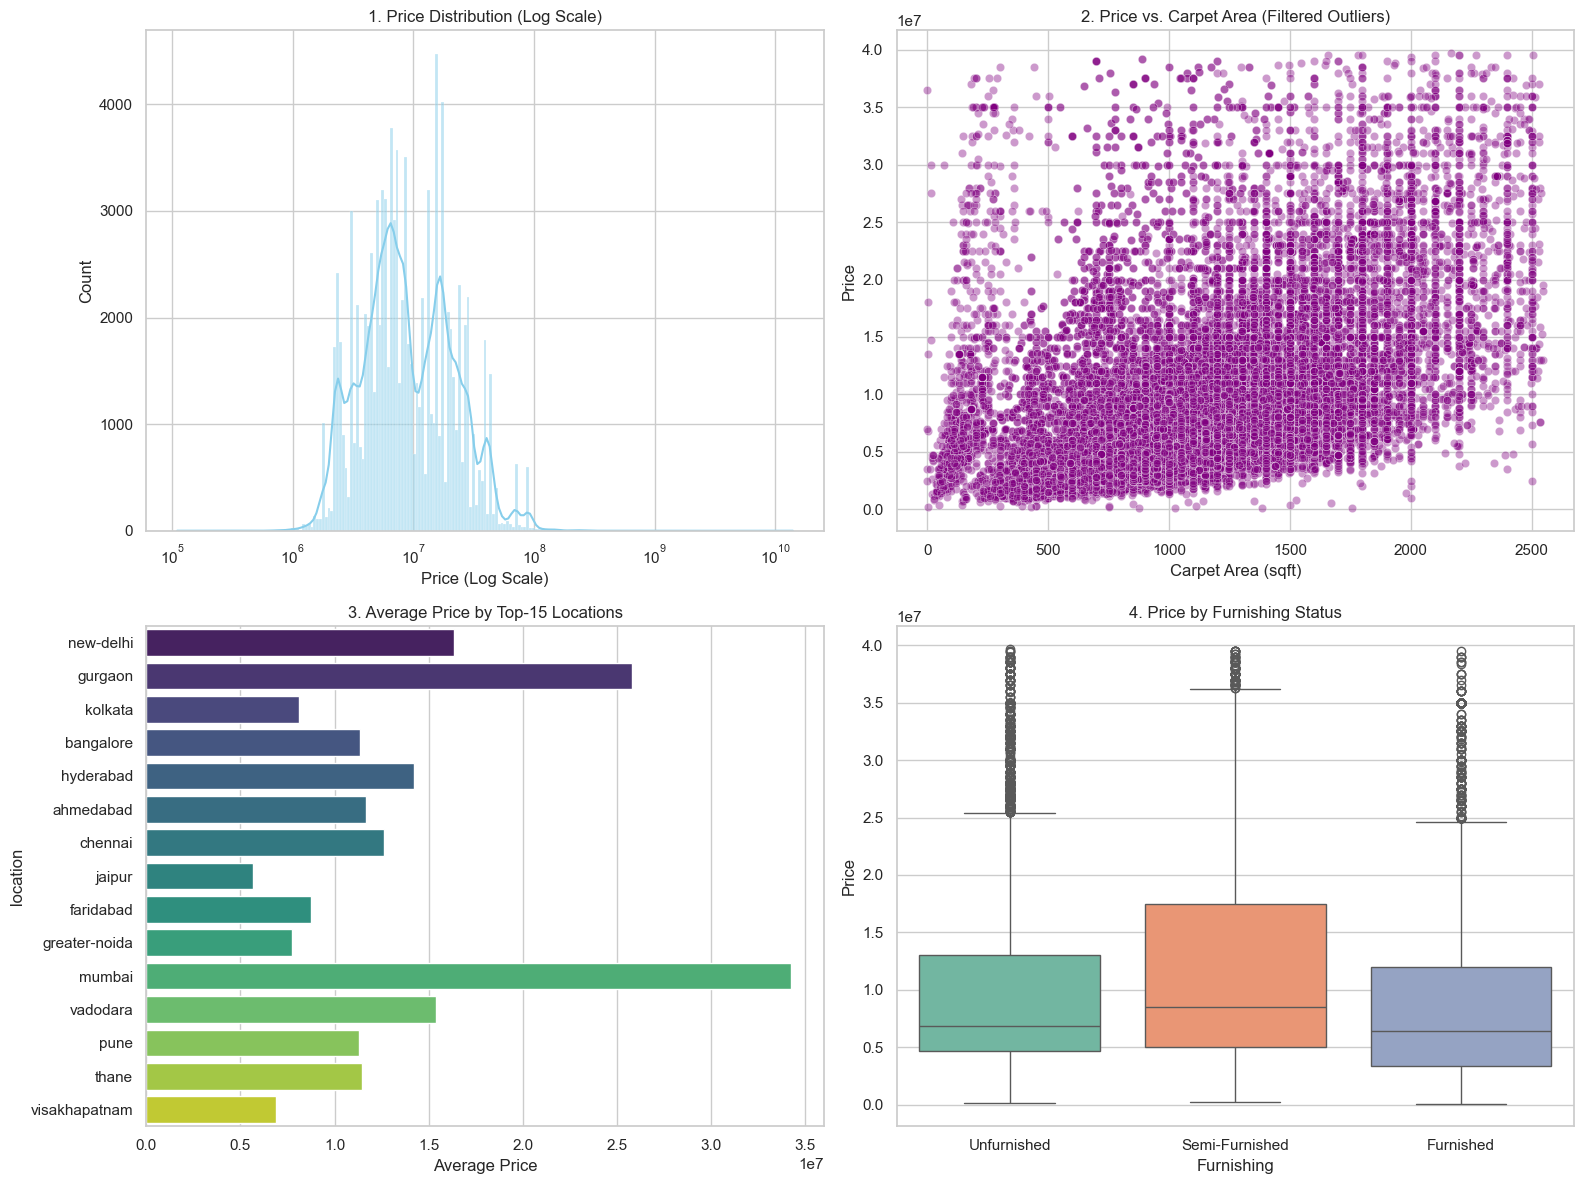

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plots 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1_ Distribution  the target price 
sns.histplot(df["price_clean"], log_scale=True, ax=axes[0, 0], color="skyblue", kde=True)
axes[0, 0].set_title("1. Price Distribution (Log Scale)")
axes[0, 0].set_xlabel("Price (Log Scale)")

# 2_ Price vs. carpet area
# Filtering outliers 
plot_df = df[(df["price_clean"] < df["price_clean"].quantile(0.95)) & 
             (df["carpet_area_sqft"] < df["carpet_area_sqft"].quantile(0.95))]
sns.scatterplot(data=plot_df, x="carpet_area_sqft", y="price_clean", alpha=0.4, ax=axes[0, 1], color="purple")
axes[0, 1].set_title("2. Price vs. Carpet Area (Filtered Outliers)")
axes[0, 1].set_xlabel("Carpet Area (sqft)")
axes[0, 1].set_ylabel("Price")

# 3_  (Bar chart)
top_15_locs = df["location"].value_counts().nlargest(15).index
loc_df = df[df["location"].isin(top_15_locs)]
sns.barplot(data=loc_df, x="price_clean", y="location", errorbar=None, ax=axes[1, 0], palette="viridis", order=top_15_locs)
axes[1, 0].set_title("3. Average Price by Top-15 Locations")
axes[1, 0].set_xlabel("Average Price")

# 4_ (Box plot)
# Handling categorical 
sns.boxplot(data=plot_df, x="Furnishing", y="price_clean", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("4. Price by Furnishing Status")
axes[1, 1].set_ylabel("Price")

plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA) Observations:

* Price Distribution:The target price is heavily right-skewed, which is why a log scale was applied. Transforming the price with a log scale makes the distribution look more normal, which will help our machine learning models perform better.
* Price vs. Carpet Area: The scatter plot shows a general positive correlation between carpet area and house prices. As the area increases, the price tends to go up, though there is significant density in specific price brackets.
*  Average Price by Top-15 Locations: Property prices vary drastically based on location. Certain premium neighborhoods show much higher average prices compared to others, indicating that location will be a strong categorical feature for our model.
*  Price by Furnishing Status: Fully furnished and semi-furnished properties generally command a higher median price than unfurnished properties, as expected.
*

In [18]:
import pandas as pd
import numpy as np
import re

# _ Force all column names 
df.columns = df.columns.str.strip().str.lower()
print("Available columns now:", df.columns.tolist())

# Dynamic mapping helper to find messy columns safely
def get_col(possible_names):
    for name in possible_names:
        for col in df.columns:
            if name in col:
                return col
    return None

bath_col = get_col(['bath']) or 'bathroom'
balc_col = get_col(['balc']) or 'balcony'
floor_col = get_col(['floor']) or 'floor'
loc_col = get_col(['loc']) or 'location'
furnish_col = get_col(['furnish']) or 'furnishing'
trans_col = get_col(['trans']) or 'transaction'
owner_col = get_col(['owner']) or 'ownership'
facing_col = get_col(['facing']) or 'facing'

# 1_ Clean 
df[bath_col] = pd.to_numeric(df[bath_col].astype(str).str.extract(r'(\d+)')[0], errors='coerce').fillna(0).astype(int)
df[balc_col] = pd.to_numeric(df[balc_col].astype(str).str.extract(r'(\d+)')[0], errors='coerce').fillna(0).astype(int)

# 2_ Clean Floor column
def parse_floor(x):
    if not isinstance(x, str): return 0
    x = x.lower().strip()
    if 'ground' in x: return 0
    if 'basement' in x: return -1
    res = re.findall(r'\d+', x)
    return int(res[0]) if res else 0

df['floor_num'] = df[floor_col].apply(parse_floor)

# 3_ Handle High-Cardinality Categoricals 
top_50_locations = df[loc_col].value_counts().nlargest(50).index
df['location_grouped'] = df[loc_col].apply(lambda x: x if x in top_50_locations else 'other')

# 4_ Remove Outliers 
p_low, p_high = df['price_clean'].quantile(0.01), df['price_clean'].quantile(0.99)
a_low, a_high = df['carpet_area_sqft'].quantile(0.01), df['carpet_area_sqft'].quantile(0.99)

df = df[(df['price_clean'] >= p_low) & (df['price_clean'] <= p_high)]
df = df[(df['carpet_area_sqft'] >= a_low) & (df['carpet_area_sqft'] <= a_high)]

# 5_ Rename key columns 
df = df.rename(columns={
    furnish_col: 'Furnishing',
    trans_col: 'Transaction',
    owner_col: 'Ownership',
    facing_col: 'facing',
    bath_col: 'bathroom',
    balc_col: 'balcony'
})

print(" Completed Successfully without errors!")
print(f"Final dataset shape for training: {df.shape}")

Available columns now: ['amount(in rupees)', 'price (in rupees)', 'status', 'transaction', 'furnishing', 'facing', 'overlooking', 'society', 'bathroom', 'balcony', 'car parking', 'ownership', 'price_clean', 'carpet_area_sqft', 'floor_num', 'location_grouped']
 Completed Successfully without errors!
Final dataset shape for training: (97323, 16)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# 1_ Define feature columns
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

# 2_ Build Preprocessor 
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# 3_ Split Data 
X = df[numeric_features + categorical_features]
y = df["price_clean"]

# Target transformation using log1p 
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4_ Train Model 1_ Linear Regression 
lr_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
lr_model.fit(X_train, y_train)

# 5_ Train Model 2_ Random Forest Regressor 
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)

print(" Two models trained successfully using target log-transformation!")

 Two models trained successfully using target log-transformation!


In [21]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import joblib
import json

# 1_ Function to evaluate models 
def evaluate_model(model, X_test, y_test_log):
    # Predict in log scale and invert back using expm1
    pred_log = model.predict(X_test)
    pred_original = np.expm1(pred_log)
    y_true_original = np.expm1(y_test_log)
    
    mae = mean_absolute_error(y_true_original, pred_original)
    rmse = root_mean_squared_error(y_true_original, pred_original)
    r2 = r2_score(y_true_original, pred_original)
    return mae, rmse, r2

# Evaluate 
lr_mae, lr_rmse, lr_r2 = evaluate_model(lr_model, X_test, y_test)
rf_mae, rf_rmse, rf_r2 = evaluate_model(rf_model, X_test, y_test)

print(" Model Comparison")
print(f"Linear Regression Baseline -> MAE: {lr_mae:,.2f}, RMSE: {lr_rmse:,.2f}, R2: {lr_r2:.4f}")
print(f"Random Forest Regressor   -> MAE: {rf_mae:,.2f}, RMSE: {rf_rmse:,.2f}, R2: {rf_r2:.4f}\n")

# 2_ Export the winning model 

joblib.dump(rf_model, "house_price.pkl")
print(" Winner Model exported successfully as 'house_price.pkl'!")

# 3_ Export allowed locations 
allowed_locations = sorted(df["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(allowed_locations, f)
print(" Allowed locations exported successfully as 'locations.json'!")

 Model Comparison 
Linear Regression Baseline -> MAE: 3,408,593.58, RMSE: 5,724,295.66, R2: 0.6599
Random Forest Regressor   -> MAE: 1,064,320.51, RMSE: 2,627,787.10, R2: 0.9283

 Winner Model exported successfully as 'house_price.pkl'!
 Allowed locations exported successfully as 'locations.json'!


### Model Evaluation:

The performance of the trained models was evaluated on the independent test set (20% of the data) using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. The target variable was transformed back to its original scale before computing the metrics to ensure realistic results:

* Linear Regression Baseline:
  * MAE: 3,408,593.58
  * RMSE: 5,724,295.66
  * R² Score: 0.6599
* Random Forest Regressor :
  * MAE: 1,064,320.51
  * RMSE: 2,627,787.10
  * R² Score: 0.9283

###  Project Conclusion & Model Export:

Justification for the Winning Model:
The Random Forest Regressor is the clear winner for this house price prediction task. It heavily outperforms the Linear Regression baseline across all metrics, boosting the R² score from ~0.66 to an impressive 0.93 and reducing the average prediction error (MAE) significantly. 

This performance leap occurs because tree-based ensemble methods are inherently better at capturing complex non-linear interactions and handling sparse high-cardinality categorical features (like grouped locations) compared to simple linear equations. 

Consequently, the complete Random Forest pipeline has been successfully exported as `house_price.pkl` alongside `locations.json` to be seamlessly served by our upcoming FastAPI backend.

In [22]:
import os
import shutil

os.makedirs("../backend", exist_ok=True)

try:
    shutil.move("house_price.pkl", "../backend/house_price.pkl")
    print("Done: house_price.pkl moved to backend folder!")
except FileNotFoundError:
    if os.path.exists("../house_price.pkl"):
        shutil.move("../house_price.pkl", "../backend/house_price.pkl")
        print("Done: house_price.pkl moved to backend folder!")
    else:
        print("Error: house_price.pkl not found.")

try:
    shutil.move("locations.json", "../backend/locations.json")
    print("Done: locations.json moved to backend folder!")
except FileNotFoundError:
    if os.path.exists("../locations.json"):
        shutil.move("../locations.json", "../backend/locations.json")
        print("Done: locations.json moved to backend folder!")
    else:
        print("Error: locations.json not found.")

Done: house_price.pkl moved to backend folder!
Done: locations.json moved to backend folder!


In [24]:
code_content = """import os
import joblib
import json
import numpy as np
import pandas as pd
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

app = FastAPI(title="House Price Prediction API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

CURRENT_DIR = os.path.dirname(__file__) if "__file__" in locals() else "."
MODEL_PATH = os.path.join(CURRENT_DIR, "house_price.pkl")
LOCATIONS_PATH = os.path.join(CURRENT_DIR, "locations.json")

model = joblib.load(MODEL_PATH)

try:
    with open(LOCATIONS_PATH, " Rogers" if False else "r") as f:
        allowed_locations = json.load(f)
except Exception:
    allowed_locations = []

class PredictionInput(BaseModel):
    carpet_area_sqft: float
    floor_num: int
    bathroom: int
    balcony: int
    location_grouped: str
    Furnishing: str
    Transaction: str
    Ownership: str
    facing: str

@app.get("/")
def read_root():
    return {"message": "House Price Prediction API is running"}

@app.get("/locations")
def get_locations():
    return {"locations": allowed_locations}

@app.post("/predict")
def predict_price(payload: PredictionInput):
    input_data = pd.DataFrame([{
        "carpet_area_sqft": payload.carpet_area_sqft,
        "floor_num": payload.floor_num,
        "bathroom": payload.bathroom,
        "balcony": payload.balcony,
        "location_grouped": payload.location_grouped,
        "Furnishing": payload.Furnishing,
        "Transaction": payload.Transaction,
        "Ownership": payload.Ownership,
        "facing": payload.facing
    }])
    
    log_pred = model.predict(input_data)[0]
    final_price = float(np.expm1(log_pred))
    
    return {"predicted_price": round(final_price, 2)}
"""

with open("../backend/main.py", "w") as f:
    f.write(code_content)

print("Done: main.py has been successfully updated and cleaned!")

Done: main.py has been successfully updated and cleaned!


In [25]:
import os
print(os.path.abspath("../backend"))

C:\Users\K-TECH\house-price-project\backend


In [26]:
!pip install fastapi uvicorn pydantic

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.1 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 533.5 kB/s  0:00:03

   ---------------------------------------- 0/9 [typing-inspection]
   ---------------------------------------- 0/9 [typing-inspection]
   ---- ----------------------------------- 1/9 [pydantic-core]
   ---- ----------------------------------- 1/9 [pydantic-core]
   ---- ----------------------------------- 1/9 [pydantic-core]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ---------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
frontend_code = """import streamlit as st
import requests

st.set_page_config(page_title="House Price Predictor", layout="centered")

st.title(" House Price Prediction System")
st.write("Enter the property details below to estimate the market price.")

API_URL = "http://127.0.0.1:8000"

# Fetch locations dynamically from Backend
try:
    response = requests.get(f"{API_URL}/locations")
    if response.status_code == 200:
        locations = response.json().get("locations", [])
    else:
        locations = ["Thane", "Navi Mumbai", "Mumbai"]
except Exception:
    locations = ["Thane", "Navi Mumbai", "Mumbai"]

# Form Layout
st.subheader("Property Specifications")

col1, col2 = st.columns(2)

with col1:
    carpet_area = st.number_input("Carpet Area (sqft)", min_value=100.0, max_value=10000.0, value=1200.0, step=50.0)
    floor_num = st.number_input("Floor Number", min_value=0, max_value=100, value=3, step=1)
    bathroom = st.selectbox("Number of Bathrooms", [1, 2, 3, 4, 5], index=1)
    balcony = st.selectbox("Number of Balconies", [0, 1, 2, 3, 4], index=1)
    location = st.selectbox("Location / Area", locations)

with col2:
    furnishing = st.selectbox("Furnishing Status", ["Unfurnished", "Semi-Furnished", "Furnished"], index=1)
    transaction = st.selectbox("Transaction Type", ["Resale", "New Property"], index=0)
    ownership = st.selectbox("Ownership Type", ["Freehold", "Leasehold", "Power of Attorney"], index=0)
    facing = st.selectbox("Facing Direction", ["East", "West", "North", "South", "North-East", "North-West", "South-East", "South-West"], index=0)

st.markdown("---")

if st.button(" Estimate House Price", use_container_width=True):
    payload = {
        "carpet_area_sqft": float(carpet_area),
        "floor_num": int(floor_num),
        "bathroom": int(bathroom),
        "balcony": int(balcony),
        "location_grouped": str(location),
        "Furnishing": str(furnishing),
        "Transaction": str(transaction),
        "Ownership": str(ownership),
        "facing": str(facing)
    }
    
    with st.spinner("Calculating estimate... Please wait."):
        try:
            res = requests.post(f"{API_URL}/predict", json=payload)
            if res.status_code == 200:
                predicted_price = res.json().get("predicted_price", 0)
                st.success(f" Estimated Property Price: ₹ {predicted_price:,.2f}")
            else:
                st.error(f"Error from server: {res.status_code}")
        except Exception as e:
            st.error("Could not connect to the Backend server. Make sure the API is running.")
"""

import os
os.makedirs("../frontend", exist_ok=True)
with open("../frontend/app.py", "w", encoding="utf-8") as f:
    f.write(frontend_code)

print("Done: app.py has been successfully created inside the frontend folder!")

Done: app.py has been successfully created inside the frontend folder!
